# Lista 4 - Tomasz Jarmoc & Mateusz Izdebski

In [ ]:
import sympy as sp
from sympy import symbols, diff, solve, sqrt, Matrix, simplify, display
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

sp.init_printing(use_unicode=True)
x, y, z, l = symbols('x y z l')

## Zadanie 1 - Ekstremum warunkowe

**Treść zadania:**
Wzgórze ma kształt stożka, który w układzie XYZ ma równanie: $z = 6 - \sqrt{3x^2 + 3y^2}$

Turysta porusza się po zboczu wzgórza w ten sposób, że rzut jego trasy na płaszczyznę XY jest prostą o równaniu: $y = x + 1$

**Szukane:** Współrzędne najwyżej położonego punktu trasy turysty.

Będziemy rozwiązywać to zadanie trzema metodami:

In [9]:
# I SPOSÓB - METODA MNOŻNIKÓW LAGRANGE'A

f = 6 - sqrt(3*x**2 + 3*y**2)
g = y - x - 1

L = f - l*g
dLdl = diff(L, l)
dLdx = diff(L, x)
dLdy = diff(L, y)

print("I. METODA MNOŻNIKÓW LAGRANGE'A")
print(f"f(x,y) = {f}")
print(f"g(x,y) = {g} = 0\n")

critical_points_raw = solve([dLdl, dLdx, dLdy], [x, y, l], dict=True)
critical_points = critical_points_raw if isinstance(critical_points_raw, list) else [critical_points_raw]

for i, cp in enumerate(critical_points):
    if isinstance(cp, dict):
        x0 = cp[x]
        y0 = cp[y]
        l0 = cp[l]
        
        dg_dx = diff(g, x)
        dg_dy = diff(g, y)
        dL_dxx = diff(L, x, 2)
        dL_dyy = diff(L, y, 2)
        dL_dxy = diff(L, x, y)
        
        H = Matrix([[0, dg_dx, dg_dy], [dg_dx, dL_dxx, dL_dxy], [dg_dy, dL_dxy, dL_dyy]])
        H_vals = H.subs({x: x0, y: y0})
        delta2 = H_vals.det()
        
        print(f"Punkt: ({x0}, {y0}, λ={l0})")
        print(f"det(Δ₂) = {delta2}")
        print(f"Typ: {'MAKSIMUM' if delta2 > 0 else 'MINIMUM' if delta2 < 0 else '??'}")
        print(f"f(x,y) = {f.subs({x: x0, y: y0})}\n")
        
        global_cp_list = [(x0, y0)]

I. METODA MNOŻNIKÓW LAGRANGE'A
f(x,y) = 6 - sqrt(3*x**2 + 3*y**2)
g(x,y) = -x + y - 1 = 0

Punkt: (-1/2, 1/2, λ=-sqrt(6)/2)
det(Δ₂) = 2*sqrt(6)
Typ: MAKSIMUM
f(x,y) = 6 - sqrt(6)/2



II. METODA GRAFICZNA
f(x, x+1) = 6 - √(6x² + 6x + 3)

Punkt ekstr.: (-1/2, 1/2), f = 6 - sqrt(6)/2


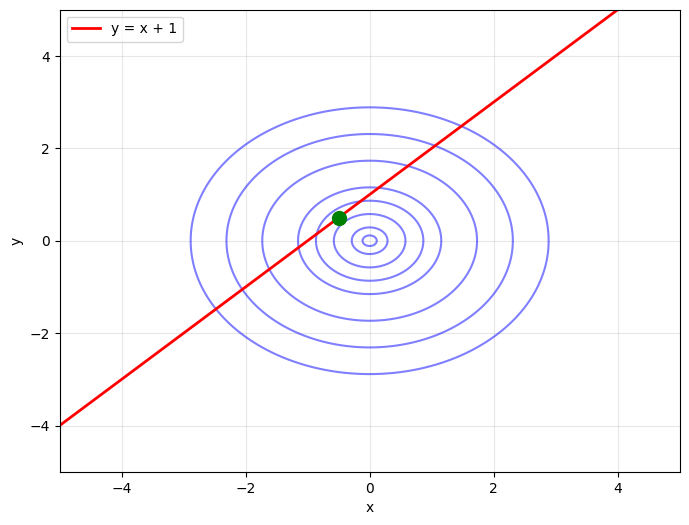

In [10]:
# METODA GRAFICZNA
expr = 6*x**2 + 6*x + 3
f_reduced = 6 - sqrt(expr)
df_reduced = diff(f_reduced, x)

print(f"f(x, x+1) = 6 - √(6x² + 6x + 3)\n")

critical_x = solve(df_reduced, x)

fig, ax = plt.subplots(figsize=(8, 6))

x_vals = np.linspace(-5, 5, 300)
y_vals = np.linspace(-5, 5, 300)
X, Y = np.meshgrid(x_vals, y_vals)
Z = 6 - np.sqrt(3*X**2 + 3*Y**2)

ax.contour(X, Y, Z, levels=[1, 2, 3, 4, 4.5, 5, 5.5, 5.8], colors='blue', alpha=0.5)
x_line = np.linspace(-5, 4, 100)
y_line = x_line + 1
ax.plot(x_line, y_line, 'r-', linewidth=2, label='y = x + 1')

for x_crit in critical_x:
    if x_crit.is_real:
        y_crit = x_crit + 1
        f_crit = f_reduced.subs(x, x_crit)
        ax.plot(float(x_crit.evalf()), float(y_crit.evalf()), 'go', markersize=10)
        print(f"Punkt ekstr.: ({x_crit}, {y_crit}), f = {f_crit}")

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [11]:
# III SPOSÓB - SPROWADZENIE DO EKSTREMUM LOKALNEGO

print("III. SPROWADZENIE DO EKSTREMUM LOKALNEGO\n")

f_single = 6 - sqrt(6*x**2 + 6*x + 3)
df_dx = diff(f_single, x)
d2f_dx2 = diff(df_dx, x)

print(f"f(x) = {f_single}\n")

critical_points_x = solve(df_dx, x)
max_point = None
max_value = -float('inf')

for x_crit in critical_points_x:
    if x_crit.is_real:
        y_crit = x_crit + 1
        z_crit = f_single.subs(x, x_crit)
        d2f_val = d2f_dx2.subs(x, x_crit)
        
        ekstremum_type = "MAX" if d2f_val < 0 else "MIN" if d2f_val > 0 else "?"
        z_val = float(z_crit.evalf())
        
        print(f"x₀ = {x_crit}, y₀ = {y_crit}")
        print(f"f''({x_crit}) = {d2f_val} → {ekstremum_type}")
        print(f"f({x_crit}, {y_crit}) = {z_crit}\n")
        
        if ekstremum_type == "MAX" and z_val > max_value:
            max_value = z_val
            max_point = (x_crit, y_crit, z_crit)

III. SPROWADZENIE DO EKSTREMUM LOKALNEGO

f(x) = 6 - sqrt(6*x**2 + 6*x + 3)

x₀ = -1/2, y₀ = 1/2
f''(-1/2) = -2*sqrt(6) → MAX
f(-1/2, 1/2) = 6 - sqrt(6)/2

